### **Blinkit Sales & Product Analytics**

### **Dataset Overview**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt      
import numpy as np  


In [2]:
df = pd.read_excel("blinkit_sales_data.xlsx")

In [3]:
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2014,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [4]:
df.tail(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8513,Regular,DRY23,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.108568,NaN,42.9112,4.0
8514,low fat,FDA11,Baking Goods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.043029,NaN,94.7436,4.0
8515,low fat,FDK38,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.053032,NaN,149.1734,4.0
8516,low fat,FDO38,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.072486,NaN,78.9986,4.0
8517,low fat,FDG32,Fruits and Vegetables,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.175143,NaN,222.3772,4.0
8518,low fat,NCT53,Health and Hygiene,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


In [5]:
df.shape

(8523, 12)

In [6]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='str')

In [7]:
df.dtypes

Item Fat Content                 str
Item Identifier                  str
Item Type                        str
Outlet Establishment Year      int64
Outlet Identifier                str
Outlet Location Type             str
Outlet Size                      str
Outlet Type                      str
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

In [8]:
print(df['Item Fat Content'].unique())

<StringArray>
['Regular', 'Low Fat', 'low fat', 'LF', 'reg']
Length: 5, dtype: str


### **Data Cleaning**

In [9]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'Low Fat':'Low Fat','low fat':'Low Fat','LF':'Low Fat','Regular':'Regular','reg':'Regular'})

In [10]:
print(df['Item Fat Content'].unique())

<StringArray>
['Regular', 'Low Fat']
Length: 2, dtype: str


In [11]:
# Total Sales
total_sales = df['Sales'].sum()

# Average Sales
average_sales = df['Sales'].mean()

# Total Items Sold
total_items_sold = df['Sales'].count()

# Average Rating
average_rating = df['Rating'].mean()

#display the results
print(f"Total Sales: ${total_sales:,.0f}")
print(f"Average Sales: ${average_sales:,.0f}")
print(f"Items Sold: {total_items_sold}")
print(f"Average Rating: {average_rating:.1f}")

Total Sales: $1,201,681
Average Sales: $141
Items Sold: 8523
Average Rating: 4.0


### **Exploratory Data Analysis**

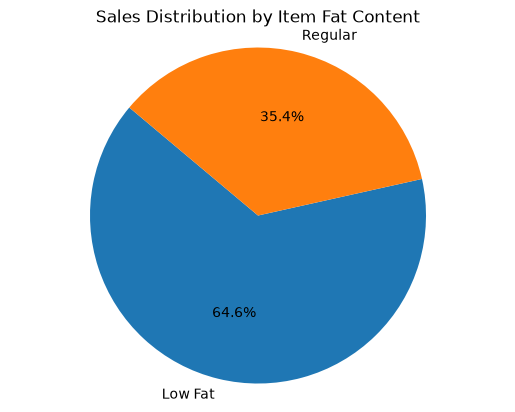

In [12]:
sale_by_fat_content = df.groupby('Item Fat Content')['Sales'].sum()

plt.pie(sale_by_fat_content, labels=sale_by_fat_content.index, autopct='%.1f%%', startangle=140)
plt.title('Sales Distribution by Item Fat Content')
plt.axis('equal')  
plt.show()

### **Sales by Item Type**

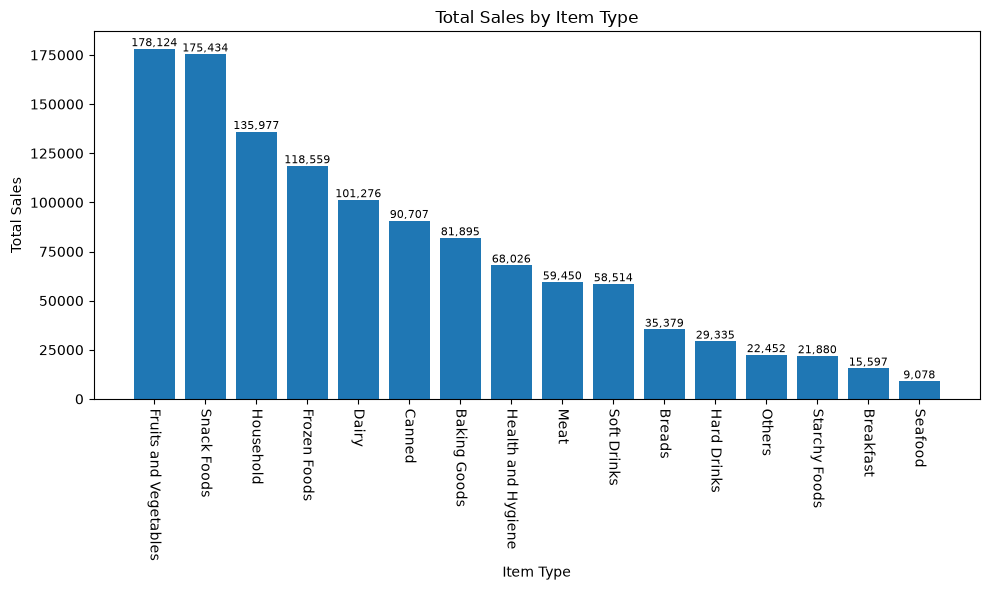

In [13]:
sales_by_item_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(sales_by_item_type.index, sales_by_item_type.values,)

plt.xticks(rotation=-90)
plt.xlabel('Item Type') 
plt.ylabel('Total Sales')
plt.title('Total Sales by Item Type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### **Sales by Item Fat Content**

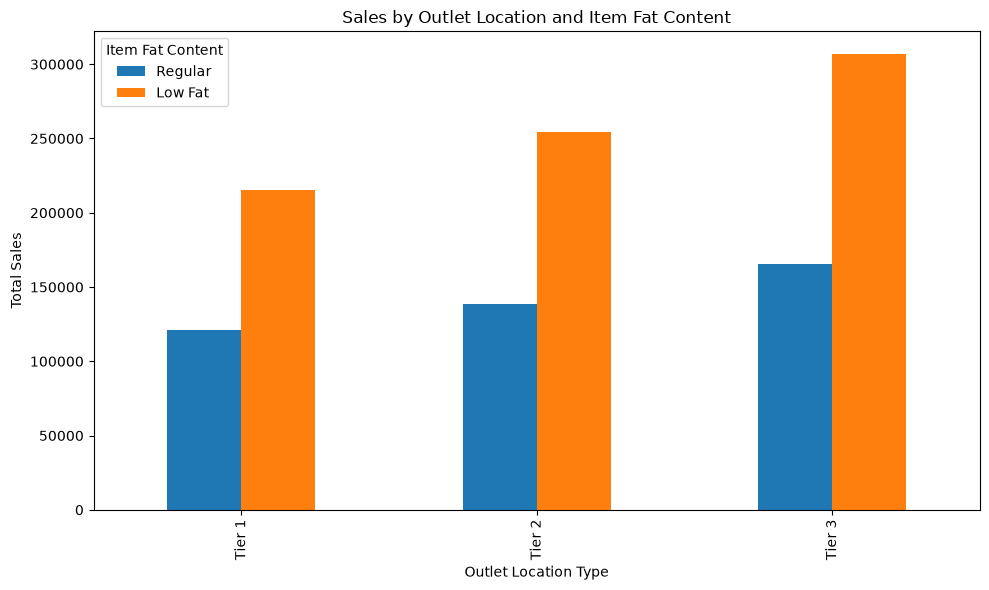

In [14]:
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular', 'Low Fat']]

ax = grouped.plot(kind='bar', figsize=(10,6))
ax.set_title('Sales by Outlet Location and Item Fat Content')
ax.set_xlabel('Outlet Location Type')
ax.set_ylabel('Total Sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()

### **Sales Trend by Outlet Establishment Year**

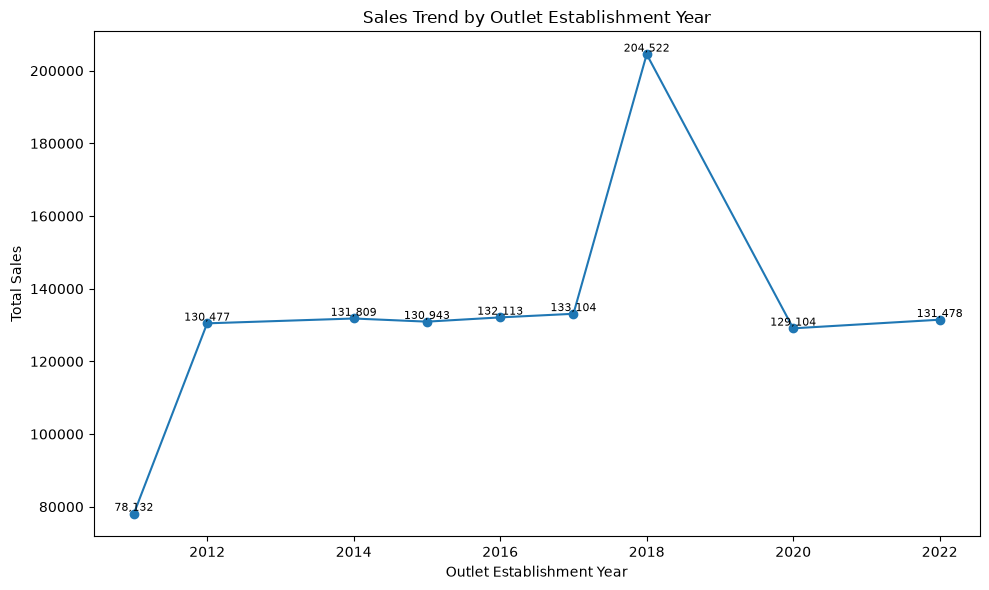

In [15]:
sale_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

plt.figure(figsize=(10,6))
plt.plot(sale_by_year.index, sale_by_year.values, marker='o', linestyle='-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')  
plt.title('Sales Trend by Outlet Establishment Year')

for x, y in zip(sale_by_year.index, sale_by_year.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()  

### **Sales by Outlet Size**

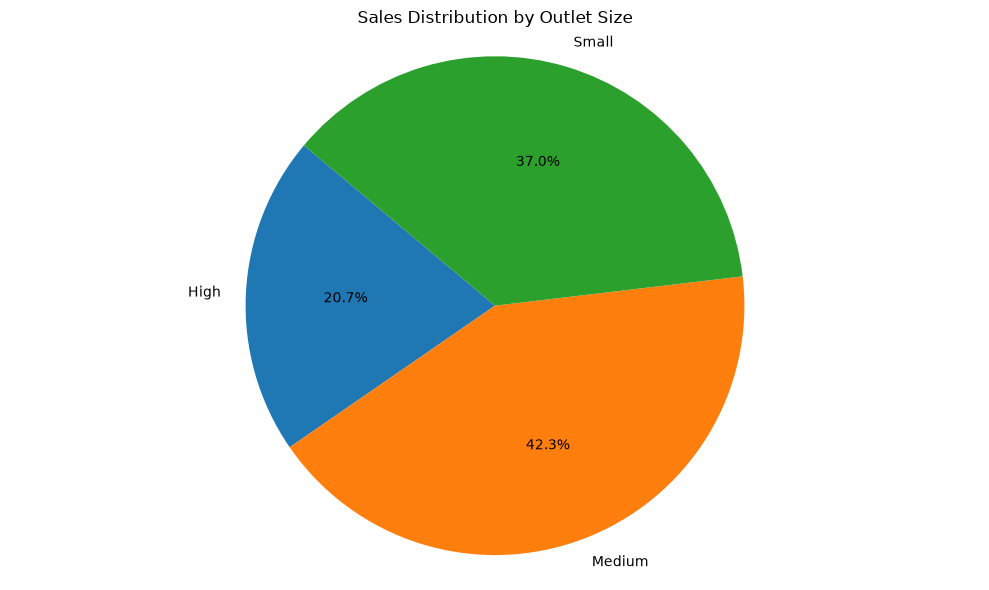

In [16]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(10,6))
plt.pie(sales_by_size, labels=sales_by_size.index, autopct='%.1f%%', startangle=140)
plt.title('Sales Distribution by Outlet Size')  
plt.axis('equal')
plt.tight_layout()
plt.show()

### **Sales by Outlet Location Type**

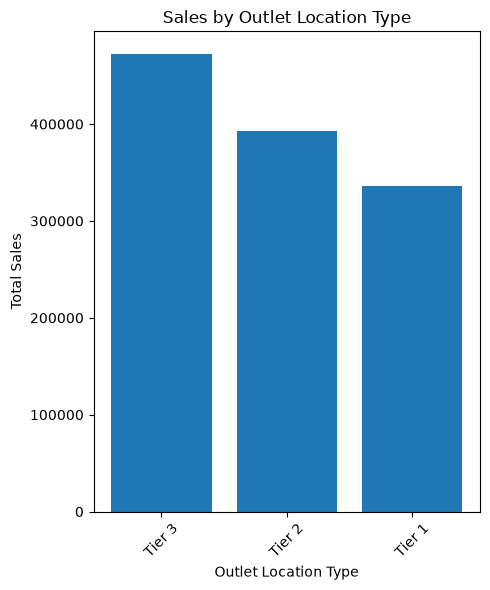

In [17]:
sale_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sale_by_location = sale_by_location.sort_values(by='Sales', ascending=False)

plt.figure(figsize=(5,6))
plt.bar(sale_by_location['Outlet Location Type'], sale_by_location['Sales'])
plt.xticks(rotation=45)
plt.xlabel('Outlet Location Type')
plt.ylabel('Total Sales')
plt.title('Sales by Outlet Location Type')
plt.tight_layout()
plt.show()

## **Key Product & Business Insights**

- Product categories contribute differently to overall sales performance.

- Outlet size and location have a significant impact on revenue generation.

- Low Fat and Regular products exhibit distinct customer demand patterns.

- Sales trends vary across outlet establishment years, indicating differences in outlet maturity and performance.

- Customer ratings provide valuable signals for understanding product quality and user preferences.

## **Data-Driven Business Recommendations**

- Prioritize inventory planning for high-performing product categories.

- Optimize product assortment based on outlet size and location demographics.

- Leverage customer preference insights to improve product positioning strategies.

- Identify underperforming outlet segments and develop targeted sales initiatives.

- Use sales and rating trends to support data-driven product and business decisions.